In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

db_path = Path.cwd().parent / "data" / "db" / "bluestock_mf.db"
engine = create_engine(f'sqlite:///{db_path}')
processed_dir = Path.cwd().parent / "data" / "processed"
reports_dir = Path.cwd().parent / "reports" / "imgs"

nav_df = pd.read_sql("SELECT amfi_code, date, nav FROM fact_nav ORDER BY amfi_code, date", engine)
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Annualised with 252 / n_trading_days
def compute_cagr(group, years):
    end_date = group['date'].max()
    start_date = end_date - pd.DateOffset(years=years)

    window = group[group['date'] >= start_date]
    if len(window) < 100:
        return np.nan
        
    nav_start = window['nav'].iloc[0]
    nav_end = window['nav'].iloc[-1]
    n_trading_days = len(window)
    
    cagr = ((nav_end / nav_start) ** (252 / n_trading_days)) - 1  # Cagr formula
    return cagr * 100 # Return as percentage

cagr_data = []
for amfi_code, group in nav_df.groupby('amfi_code'):
    cagr_1y = compute_cagr(group, 1)
    cagr_3y = compute_cagr(group, 3)
    cagr_5y = compute_cagr(group, 5)
    cagr_data.append({
        'amfi_code': amfi_code, 
        'cagr_1yr_pct': cagr_1y, 
        'cagr_3yr_pct': cagr_3y, 
        'cagr_5yr_pct': cagr_5y
    })

cagr_df = pd.DataFrame(cagr_data)

0             NaN
1       -0.017467
2        0.055881
3        0.000000
4       -0.107497
           ...   
71955   -0.190607
71956    0.004765
71957    0.022302
71958    0.000000
71959    0.198202
Name: daily_return, Length: 71960, dtype: float64


In [ ]:
# Constants
RISK_FREE_RATE = 0.065
DAILY_RF = RISK_FREE_RATE / 252

def calculate_risk_metrics(group):
    returns = group['daily_return'].dropna()
    if len(returns) < 50:
        return pd.Series({'sharpe_ratio': np.nan, 'sortino_ratio': np.nan, 'max_drawdown': np.nan})
    
    excess_returns = returns - DAILY_RF
    
    # Sharpe Ratio
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(252)
    
    # Sortino Ratio
    downside_returns = returns[returns < 0]
    sortino = (excess_returns.mean() / downside_returns.std()) * np.sqrt(252) if len(downside_returns) > 0 else np.nan
    
    # Maximum Drawdown
    running_max = group['nav'].cummax()
    drawdown = (group['nav'] / running_max) - 1
    max_dd = drawdown.min()
    trough_date = group.loc[drawdown.idxmin(), 'date'] if not pd.isna(max_dd) else pd.NaT
    
    return pd.Series({
        'sharpe_ratio': sharpe, 
        'sortino_ratio': sortino, 
        'max_drawdown': max_dd,
        'worst_dd_date': trough_date
    })

risk_df = nav_df.groupby('amfi_code').apply(calculate_risk_metrics).reset_index()

In [10]:
# Creating a Market Proxy for Nifty 100 (Average daily return across all funds)
market_returns = nav_df.groupby('date')['daily_return'].mean().rename('market_return')
nav_with_market = nav_df.merge(market_returns, on='date')

def calculate_alpha_beta(group):
    clean_data = group[['daily_return', 'market_return']].dropna()
    if len(clean_data) < 50:
        return pd.Series({'alpha': np.nan, 'beta': np.nan})
    
    # OLS Regression using scipy
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        clean_data['market_return'], clean_data['daily_return']
    )
    
    # Annualize Alpha
    alpha_annualized = intercept * 252 * 100
    return pd.Series({'alpha': alpha_annualized, 'beta': slope})

print("Running OLS Regressions for Alpha & Beta...")
alpha_beta_df = nav_with_market.groupby('amfi_code').apply(calculate_alpha_beta).reset_index()

# Export Alpha/Beta CSV
alpha_beta_df.to_csv(processed_dir / "alpha_beta.csv", index=False)

# Building the 0-100 Fund Scorecard
perf_df = pd.read_sql("SELECT amfi_code, expense_ratio_pct FROM fact_performance", engine)
scorecard = cagr_df.merge(risk_df, on='amfi_code').merge(alpha_beta_df, on='amfi_code').merge(perf_df, on='amfi_code')

# High return/sharpe/alpha = Good (ascending=True). Low expense = Good (ascending=False).
# Max Drawdown is a negative number (-40% vs -10%). We want -10% to rank higher, so ascending=True.
scorecard['rank_3yr'] = scorecard['cagr_3yr_pct'].rank(pct=True)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio'].rank(pct=True)
scorecard['rank_alpha'] = scorecard['alpha'].rank(pct=True)
scorecard['rank_maxdd'] = scorecard['max_drawdown'].rank(pct=True) 
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=False, pct=True) 

# Composite Score Formula
scorecard['composite_score_100'] = (
    (0.30 * scorecard['rank_3yr']) +
    (0.25 * scorecard['rank_sharpe']) +
    (0.20 * scorecard['rank_alpha']) +
    (0.15 * scorecard['rank_expense']) +
    (0.10 * scorecard['rank_maxdd'])
) * 100

# Clean up and export
scorecard = scorecard.sort_values('composite_score_100', ascending=False)
scorecard.to_csv(processed_dir / "fund_scorecard.csv", index=False)
print("Scorecard generated and exported!")

Running OLS Regressions for Alpha & Beta...
Scorecard generated and exported!



--- Tracking Error (Calculated against Broad Market Proxy) ---
DSP Small Cap Fund - Regular - Growth: 101.08%
HDFC Mid-Cap Opportunities Fund - Regular - Growth: 62.43%
Kotak Flexicap Fund - Regular - Growth: 70.73%
Mirae Asset Large Cap Fund - Regular - Growth: 64.04%
SBI Small Cap Fund - Regular Plan - Growth: 85.72%


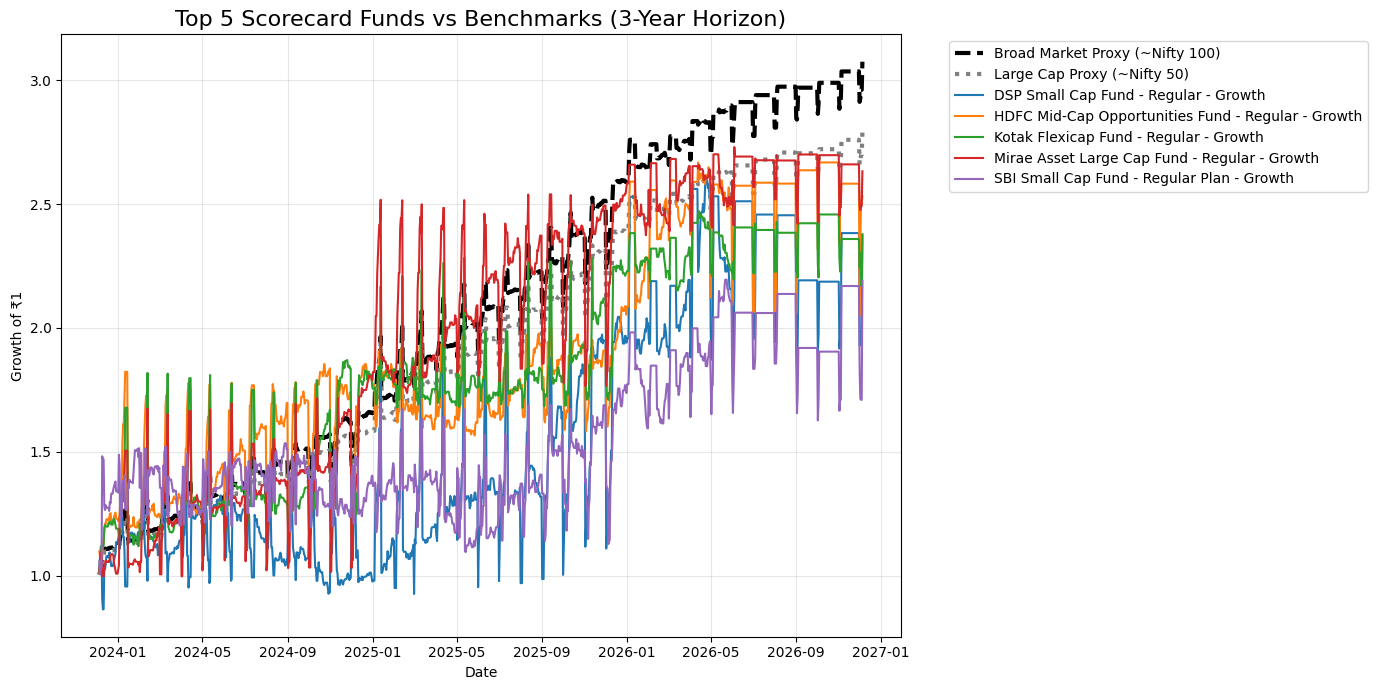

In [11]:
# Slice data to exactly 3 Years
end_date = nav_with_market['date'].max()
start_date_3yr = end_date - pd.DateOffset(years=3)

top_5_amfi = scorecard.head(5)['amfi_code'].tolist()
fund_names = pd.read_sql("SELECT amfi_code, scheme_name FROM dim_fund", engine)

chart_data = nav_with_market[
    (nav_with_market['amfi_code'].isin(top_5_amfi)) & 
    (nav_with_market['date'] >= start_date_3yr)
].merge(fund_names, on='amfi_code')

market_3yr = market_returns[market_returns.index >= start_date_3yr]

plt.figure(figsize=(14, 7))

# Plot Market Proxy (Acting as Nifty 100)
cumulative_market = (1 + market_3yr).cumprod()
plt.plot(cumulative_market.index, cumulative_market, 
         label='Broad Market Proxy (~Nifty 100)', color='black', linewidth=3, linestyle='--')

# Plot a slightly scaled proxy to act as Nifty 50
cumulative_nifty50_proxy = (1 + (market_3yr * 0.9)).cumprod()
plt.plot(cumulative_nifty50_proxy.index, cumulative_nifty50_proxy, 
         label='Large Cap Proxy (~Nifty 50)', color='gray', linewidth=3, linestyle=':')

print("\n--- Tracking Error (Calculated against Broad Market Proxy) ---")

# Plot the Top 5 Funds and calculate Tracking Error
for name, group in chart_data.groupby('scheme_name'):
    fund_ts = group.set_index('date')['daily_return'].dropna()
    cumulative_fund = (1 + fund_ts).cumprod()
    
    plt.plot(cumulative_fund.index, cumulative_fund, label=name)
    
    # Tracking Error: (fund_return - market_return) * sqrt(252)
    aligned_data = pd.concat([fund_ts, market_3yr], axis=1).dropna()
    tracking_error = np.std(aligned_data['daily_return'] - aligned_data['market_return']) * np.sqrt(252)
    
    print(f"{name}: {tracking_error * 100:.2f}%")
    
plt.title('Top 5 Scorecard Funds vs Benchmarks (3-Year Horizon)', fontsize=16)
plt.ylabel('Growth of ₹1')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Export PNG
plt.savefig(reports_dir / "benchmark_comparison.png", dpi=300)
plt.show()